<a href="https://colab.research.google.com/github/Chandhana-sanoj/ICT_DSA_2026/blob/main/Computer_Vision_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt
import numpy as np

#Load Data

In [2]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


#Normalize images

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

#Convert labels

In [4]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

##Check sample images

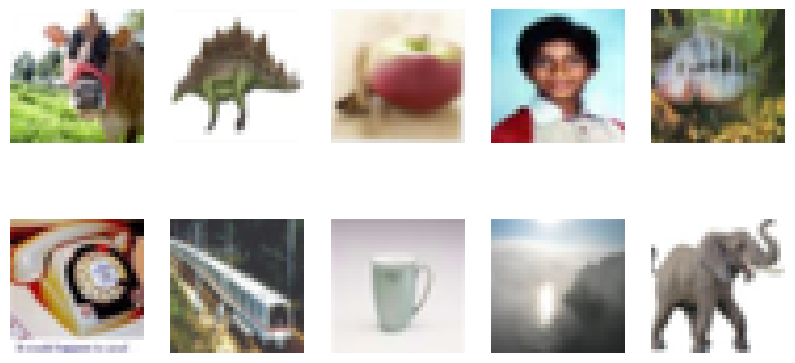

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.show()

#CNN Architecture

In [6]:
custom_cnn = models.Sequential([

    # First CNN Block
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),


    # Second CNN Block
    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.3),


    # Dense Layers
    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu',
        kernel_initializer='he_normal'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        100,
        activation='softmax'
    )
])

custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,140,868 (4.35 MB)

 Trainable params: 1,140,484 (4.35 MB)

 Non-trainable params: 384 (1.50 KB)

#Compile Model

In [7]:
custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Add callbacks

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_custom_cnn.keras",
    save_best_only=True
)

#Train CNN

In [10]:
history_custom = custom_cnn.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,

    validation_data=(x_test, y_test),

    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5552 - loss: 1.5686 - val_accuracy: 0.5078 - val_loss: 1.8489
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5589 - loss: 1.5367 - val_accuracy: 0.5038 - val_loss: 1.8656
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5651 - loss: 1.5114 - val_accuracy: 0.5119 - val_loss: 1.8375
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5752 - loss: 1.4689 - val_accuracy: 0.5040 - val_loss: 1.8783
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5799 - loss: 1.4557 - val_accuracy: 0.5151 - val_loss: 1.8557


#Evaluate CNN

In [11]:
test_loss, test_accuracy = custom_cnn.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5078 - loss: 1.8489
Test Accuracy: 0.5077999830245972


#Accuracy Graph

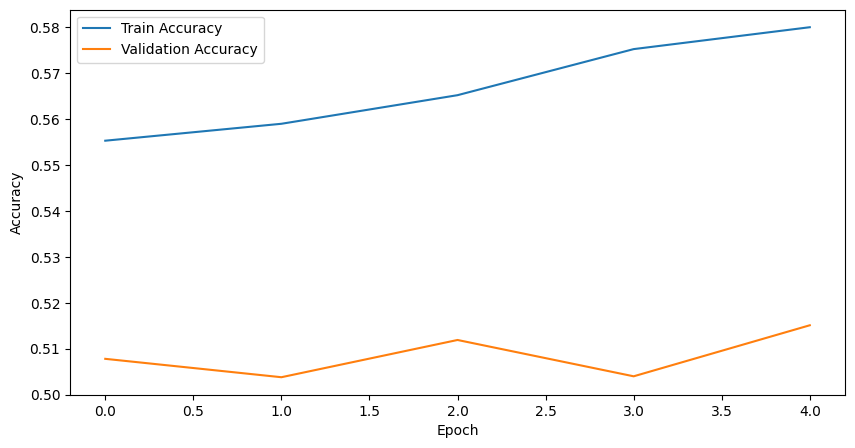

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    history_custom.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_custom.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

#Loss Graph

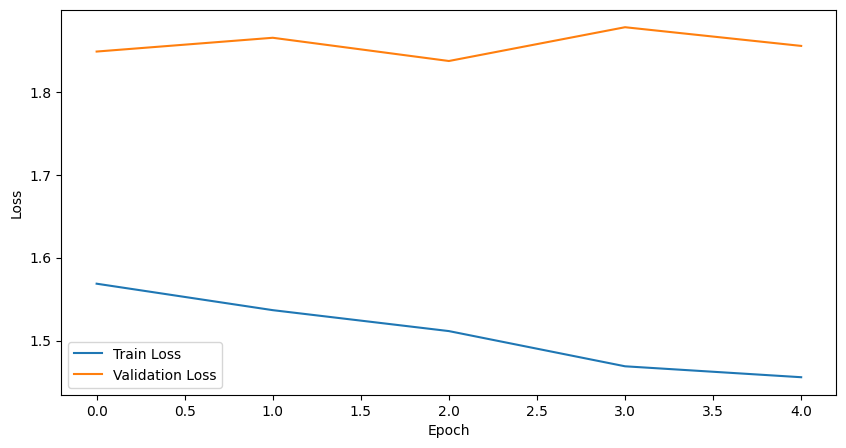

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    history_custom.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_custom.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
tf.keras.backend.clear_session()

#Import VGG16

In [2]:
from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input,
    GlobalAveragePooling2D,
    Resizing
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import ModelCheckpoint

In [14]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input,
    GlobalAveragePooling2D,
    Resizing
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in vgg_base.layers[:-4]:
    layer.trainable = False
for layer in vgg_base.layers[-4:]:
    layer.trainable = True

vgg_model = Sequential([
    Input(shape=(32,32,3)),
    Resizing(
        224,
        224
    ),
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(
        512,
        activation='relu'
    ),
    Dropout(0.5),
    Dense(
        100,
        activation='softmax'
    )
])

vgg_model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "best_vgg.keras",
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 7,393,380 (28.20 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

#Load VGG16 base

In [15]:
from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Input,
    GlobalAveragePooling2D,
    Resizing
)

from tensorflow.keras.callbacks import (
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

In [16]:
vgg_base = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

In [17]:
for layer in vgg_base.layers[:-4]:

    layer.trainable = False

for layer in vgg_base.layers[-4:]:

    layer.trainable = True

#Build model

In [18]:
vgg_model = Sequential([

    Input(shape=(32,32,3)),

    Resizing(
        224,
        224
    ),

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(
        512,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        100,
        activation='softmax'
    )

])

vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 7,393,380 (28.20 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [4]:
vgg_base = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Compile

In [19]:
vgg_model.compile(

    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [20]:
checkpoint = ModelCheckpoint(

    "best_vgg.keras",

    save_best_only=True,

    monitor='val_accuracy',

    mode='max'

)

#Train VGG16

In [ ]:
history_vgg = vgg_model.fit(

    x_train,

    y_train,

    epochs=20,

    batch_size=64,

    validation_data=(
        x_test,
        y_test
    ),

    callbacks=[
        checkpoint
    ]

)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 348s 407ms/step - accuracy: 0.1104 - loss: 3.8648 - val_accuracy: 0.2858 - val_loss: 2.9184
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 305s 390ms/step - accuracy: 0.2744 - loss: 2.8637 - val_accuracy: 0.3875 - val_loss: 2.3675
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 305s 390ms/step - accuracy: 0.3704 - loss: 2.3960 - val_accuracy: 0.4573 - val_loss: 2.0686
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 305s 390ms/step - accuracy: 0.4338 - loss: 2.1075 - val_accuracy: 0.4934 - val_loss: 1.9192
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 305s 390ms/step - accuracy: 0.4839 - loss: 1.8901 - val_accuracy: 0.5197 - val_loss: 1.7974
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 304s 389ms/step - accuracy: 0.5220 - loss: 1.7314 - val_accuracy: 0.5388 - val_loss: 1.6956
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 305s 390ms/step - accuracy: 0.5552 - loss: 1.5869 - val_accuracy: 0.5705 - val_loss: 1.5694
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 304s 389ms/step - accuracy: 0.5882 -